In [9]:
import os, subprocess, multiprocessing
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re 

log_path = "/home/mohammad/spain/experiments/astra-sim/upc/output/1_8_4_2_1.log"


log_filename = os.path.split(log_path)[-1]
dp, mp, sp, pp, sharded = log_filename[:-4].split('_')
dp, mp, sp, pp, sharded = int(dp), int(mp), int(sp), int(pp), int(sharded)
runtime = 0

with open(log_path, 'r') as f:
    log_lines = f.readlines()

if len(log_lines) < 2:
    print(dp, mp, sp, pp, sharded, -1 ) # Not enough lines in log file


pattern = r"(\d+) cycles, exposed communication (\d+) cycles"

# Lists to store extracted values
execution_cycles = []
communication_cycles = []



with open(log_path, "r") as file:
    log_data = file.read()
    # Find matches in the log data
    matches = re.findall(pattern, log_data)

    # Store extracted values in separate lists
    for exec_cycles, comm_cycles in matches:
        execution_cycles.append(int(exec_cycles))
        communication_cycles.append(int(comm_cycles))

    # Output results
    print("Execution Cycles:", execution_cycles)
    print("Communication Cycles:", communication_cycles)


Execution Cycles: [107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107247358680, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378, 107259333378]
Communication Cycles: [107247358068, 107247358068, 107247358068, 107247358068, 107247358068, 107247358068, 107247358068, 107247358068, 107247358068, 107247358068, 107247358068, 107247358068, 107247358068, 107247358068, 107247358068, 107247358068, 107247358068, 107247358068, 107247358068, 107247358068, 107247

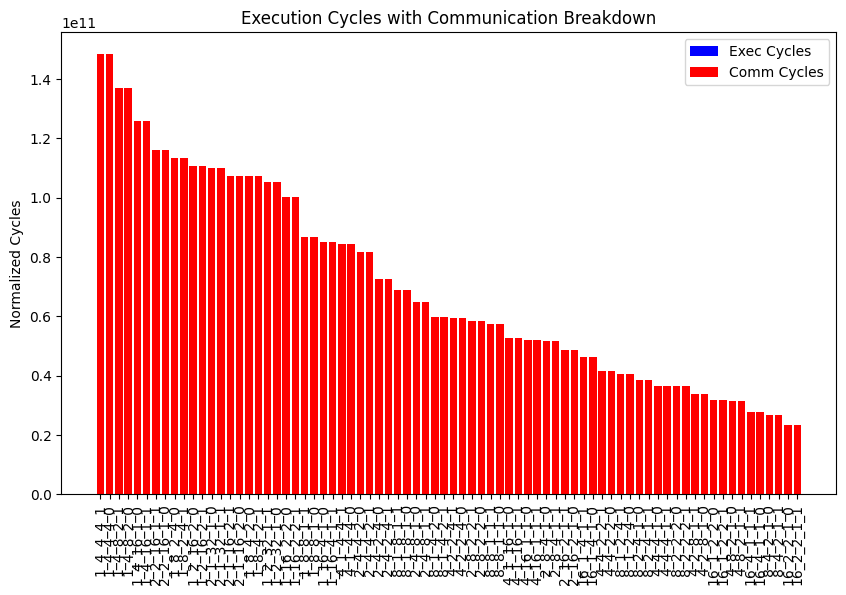

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv('./results/GPT3/3D_Torus.csv')

# Normalize exec_cycles and comm_cycles
df['exec_cycles_norm'] = df['exec_cycles'] #- df['exec_cycles'].min()) / (df['exec_cycles'].max() - df['exec_cycles'].min())
df['comm_cycles_norm'] = df['comm_cycles'] #- df['exec_cycles'].min()) / (df['exec_cycles'].max() - df['exec_cycles'].min())

# Sort data for better visualization
df = df.sort_values(by='exec_cycles_norm', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(df))

# Plot total exec_cycles as bars
ax.bar(y_pos, df['exec_cycles_norm'], color='blue', label='Exec Cycles')

# Overlay comm_cycles portion
ax.bar(y_pos, df['comm_cycles_norm'], color='red', label='Comm Cycles')

# Labels and formatting
ax.set_xticks(y_pos)
ax.set_xticklabels(df['dp_mp_sp_pp_sharded'], rotation=90)
ax.set_ylabel('Normalized Cycles')
ax.set_title('Execution Cycles with Communication Breakdown')
ax.legend()

plt.show()


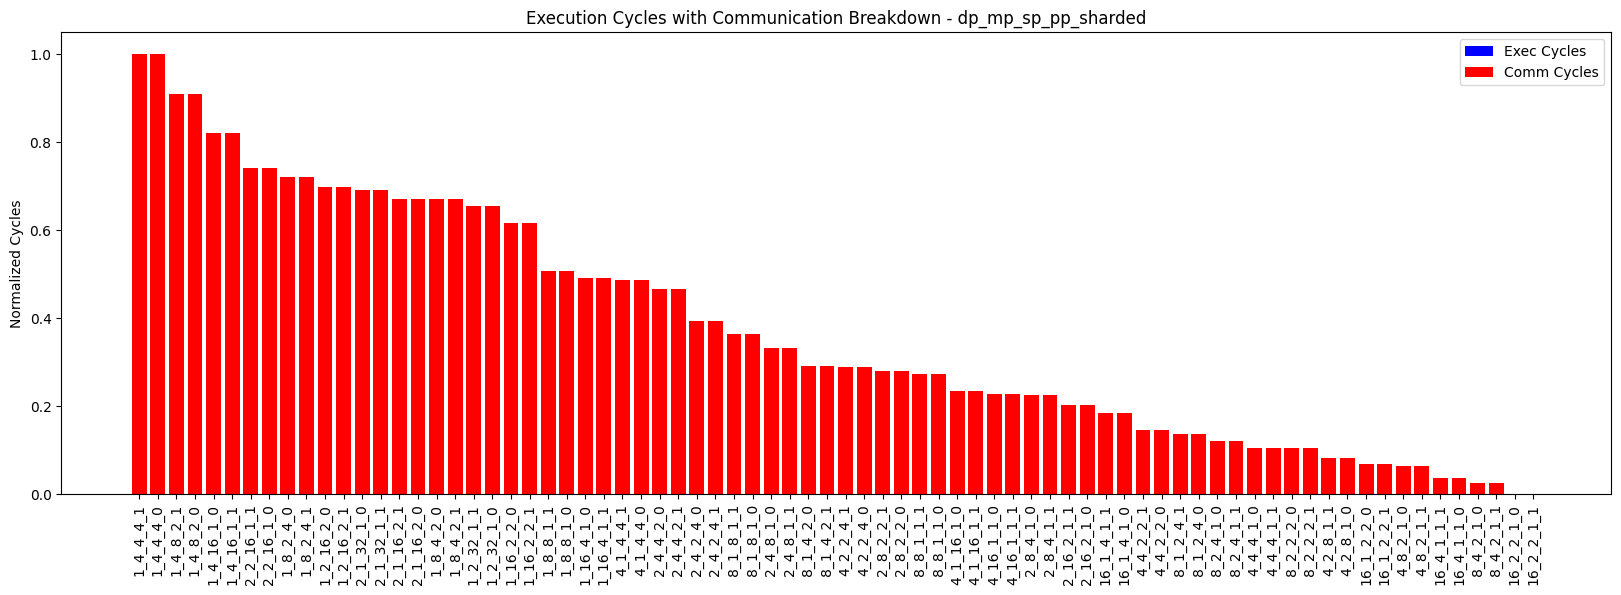

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#def plot_cycles(csv_file):
csv_file = './results/GPT3/3D_Torus.csv'
df = pd.read_csv(csv_file)
df["exec_cycles"] = df["exec_cycles"].astype(float)
df["comm_cycles"] = df["comm_cycles"].astype(float)

# Normalize values
df["exec_cycles_norm"] = (df["exec_cycles"] - df['exec_cycles'].min()) / (df['exec_cycles'].max() - df['exec_cycles'].min())
df["comm_cycles_norm"] = (df["comm_cycles"] - df['comm_cycles'].min()) / (df['comm_cycles'].max() - df['comm_cycles'].min())

#df["exec_cycles_norm"] = df["exec_cycles"] 
#df["comm_cycles_norm"] = df["comm_cycles"]

df = df.sort_values(by='exec_cycles_norm', ascending=False)
chunk_size = 100
num_chunks = (len(df) + chunk_size - 1) // chunk_size

for i in range(num_chunks):
    chunk = df.iloc[i * chunk_size:(i + 1) * chunk_size]
    
    fig, ax = plt.subplots(figsize=(20, 6))
    y_pos = np.arange(len(chunk))

    # Plot total exec_cycles as bars
    ax.bar(y_pos, chunk['exec_cycles_norm'], color='blue', label='Exec Cycles')

    # Overlay comm_cycles portion
    ax.bar(y_pos, chunk['comm_cycles_norm'], color='red', label='Comm Cycles')

    # Labels and formatting
    ax.set_xticks(y_pos)
    ax.set_xticklabels(chunk['dp_mp_sp_pp_sharded'], rotation=90)
    ax.set_ylabel('Normalized Cycles')
    ax.set_title('Execution Cycles with Communication Breakdown - dp_mp_sp_pp_sharded')
    ax.legend()

    plt.show()

# Example usage:
# plot_cycles("your_file.csv")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

res_dir_path = "./results/GPT3/"
files = os.listdir(res_dir_path)

df = pd.DataFrame()
for file in files:
    if file.endswith(".csv"):
        csv_file_path = os.path.join(res_dir_path, file)
        tmp_df = pd.read_csv(csv_file_path)
        tmp_df["file"] = [file[:-4]] * len(tmp_df)
        df = pd.concat([df, tmp_df])
        
dp = 4 
mp = 4
sp = 2
pp = 2
sharded = 0
parallelism_strategy = f"{dp}_{mp}_{sp}_{pp}_{sharded}"
df_to_plot = df[df["dp_mp_sp_pp_sharded"] == parallelism_strategy]



df_to_plot.loc[:, "exec_cycles"] = df_to_plot["exec_cycles"].astype(float)
df_to_plot.loc[:, "comm_cycles"] = df_to_plot["comm_cycles"].astype(float)


df_to_plot = df_to_plot.sort_values(by='file')

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(df_to_plot))

# Plot total exec_cycles as bars
ax.bar(y_pos, df_to_plot['exec_cycles'], color='blue', label='Exec Cycles')

# Overlay comm_cycles portion
ax.bar(y_pos, df_to_plot['comm_cycles'], color='red', label='Comm Cycles')

# Labels and formatting
ax.set_xticks(y_pos)
ax.set_xticklabels(df_to_plot['dp_mp_sp_pp_sharded'], rotation=90)
ax.set_ylabel('Normalized Cycles')
ax.set_title('Execution Cycles with Communication Breakdown - dp_mp_sp_pp_sharded')
ax.legend()

plt.show()

/tmp/ipykernel_20738/4254545291.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_plot.loc[:, "exec_cycles_norm"] = df_to_plot["exec_cycles"]
/tmp/ipykernel_20738/4254545291.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_plot.loc[:, "comm_cycles_norm"] = df_to_plot["comm_cycles"]


,dp_mp_sp_pp_sharded,dp,mp,sp,pp,sharded,exec_cycles,comm_cycles,file,exec_cycles_norm,comm_cycles_norm
23,4_4_2_2_0,4,4,2,2,0,4.149268e+10,4.149268e+10,2D_Torus,4.149268e+10,4.149268e+10
36,4_4_2_2_0,4,4,2,2,0,4.148763e+10,4.148763e+10,3D_Torus,4.148763e+10,4.148763e+10
36,4_4_2_2_0,4,4,2,2,0,4.148925e+10,4.148925e+10,DGX1,4.148925e+10,4.148925e+10
36,4_4_2_2_0,4,4,2,2,0,4.149250e+10,4.149250e+10,DGX_H100,4.149250e+10,4.149250e+10
36,4_4_2_2_0,4,4,2,2,0,4.148760e+10,4.148760e+10,Dragonfly,4.148760e+10,4.148760e+10
36,4_4_2_2_0,4,4,2,2,0,5.373994e+10,5.373994e+10,FullyConnected,5.373994e+10,5.373994e+10
36,4_4_2_2_0,4,4,2,2,0,5.376687e+10,5.376687e+10,Ring,5.376687e+10,5.376687e+10
36,4_4_2_2_0,4,4,2,2,0,5.374484e+10,5.374484e+10,Switch,5.374484e+10,5.374484e+10
